## 스프린트 미션 소개

이번 미션에서는 Hotel Booking Demand Datasets를 분석해볼 예정입니다.

해당 데이터는 2015.07.01부터 2017.08.31까지의 Resort Hotel과 City Hotel의 예약 데이터를 포함하고 있습니다.

예약 취소는 호텔의 매출에 영향을 끼치는 요소 중 하나인데요, 지금부터 여러분이 City Hotel과 Resort Hotel의 관리인이라고 상상해 보세요. 호텔 관리인으로서 예약 취소와 관련이 있는 요소들을 파악해보고, 예약 취소율을 줄이기 위한 아이디어도 생각해 볼 겁니다. 어떤 조건에서 예약 취소가 빈번하게 발생하는지, 예약 취소와 관련이 있는 요소들이 무엇인지 파악해보고, 마지막으로 어떻게 하면 예약 취소율을 개선할 수 있을지 아이디어도 얻어 보세요!

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [67]:
hotel = pd.read_csv("data/hotel_data_modified.csv") 
print("hotel.shape:", hotel.shape)
print("hotel columns:", hotel.columns)
print("hotel.dtypes:\n",hotel.dtypes)


hotel.shape: (119390, 29)
hotel columns: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date'],
      dtype='str')


In [163]:
################################################################################################
##### 중복 데이터 확인
################################################################################################
## 
print("중복 레코드 갯수:", hotel.duplicated().sum() ) # 중복 레코드 갯수: 119390
#hotel.loc[hotel["company"].duplicated(keep=False)].sort_values(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights' ]).head()

##### 중복 데이터 제거
hotel2 = hotel.drop_duplicates()
print("중복 레코드 갯수:", hotel2.duplicated().sum() ) #중복 레코드 갯수: 86287

##### 결론: 중복건은 제거하지 않는다 = 사유는 방을 여러가 예약하기 위해 같은 조건으로 여러건 예약한 것으로 판단 
## 제거할 컬럼: adults , children, babies, 
## 주요 점검할 컬럼: country
## company 컬럼에 0 이면 미수가 없음으로
## 주요 컬럼 : is_canceled = 1 

################################################################################################
# 컬럼별 결측치 개수 확인
################################################################################################
print()
#print("결측치 수량:\n", hotel.isna().sum())
null_counts = hotel.isna().sum()
print("결측치 컬럼 :\n", null_counts[null_counts > 0])

################################################################################################
# 문자열(object) 타입의 컬럼만 선택
################################################################################################
print()
print("문자열 타입의 스페이스 탭 엔터 검토")
string_columns = hotel.select_dtypes(include=['str']).columns

################################################################################################
# 컬럼별로 앞뒤 공백이 포함된 레코드 개수 확인
################################################################################################
for col in string_columns:
    # 문자열로 변환 후, 원래 값과 앞뒤 공백을 제거(strip)한 값이 다른지 비교
    space_count = (hotel[col].astype(str).str.strip() != hotel[col].astype(str)).sum()
    if space_count > 0:
        print(f"[{col}] 컬럼에 공백이 포함된 데이터: {space_count}개")




중복 레코드 갯수: 33103
중복 레코드 갯수: 0

결측치 컬럼 :
 children         4
country        488
agent        16340
company     112593
dtype: int64

문자열 타입의 스페이스 탭 엔터 검토
[country] 컬럼에 공백이 포함된 데이터: 488개


C:\Users\dsbang\AppData\Local\Temp\ipykernel_2340\3133646660.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x="agent", y="mean", data=df_sub, palette="viridis")
C:\Users\dsbang\AppData\Local\Temp\ipykernel_2340\3133646660.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x="agent", y="mean", data=df_sub, palette="viridis")


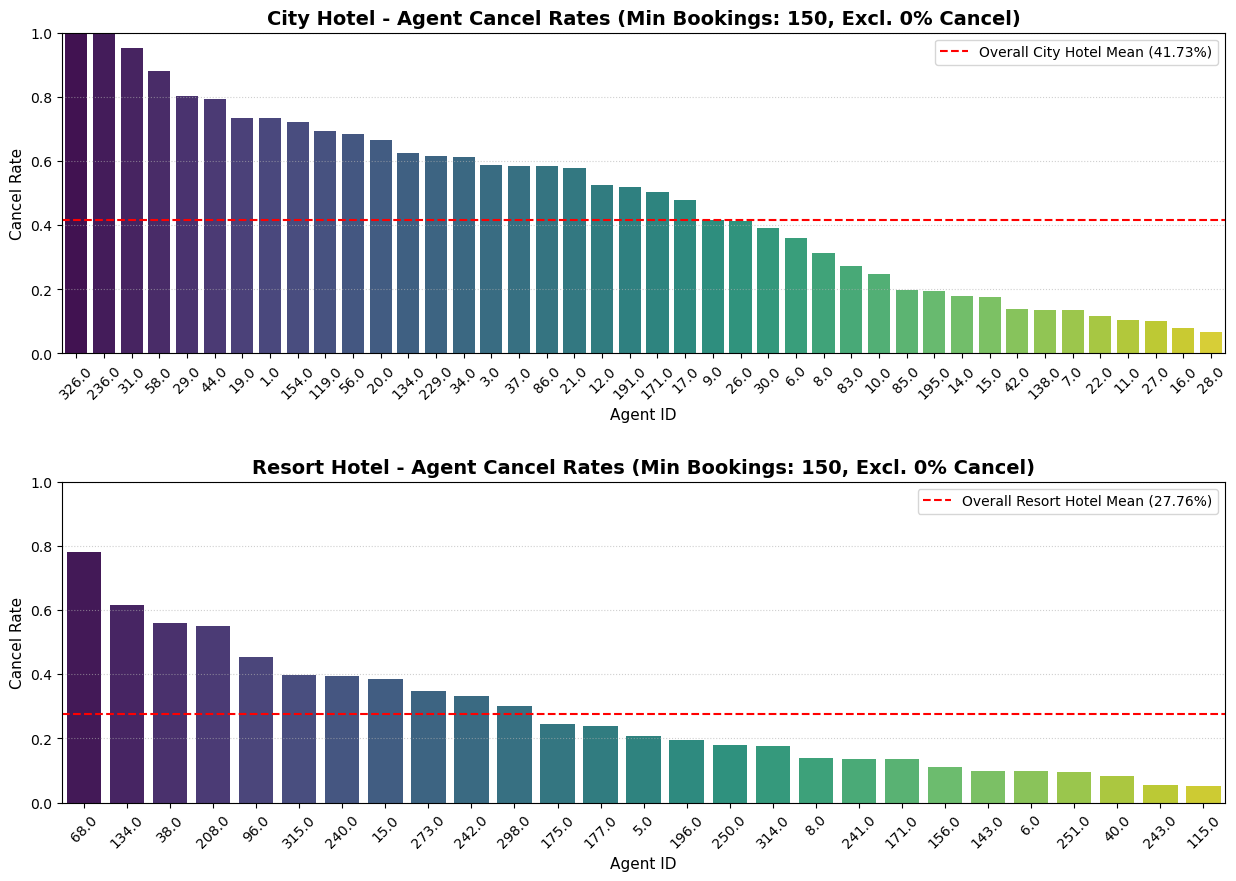

In [187]:
# 1. 호텔별 총 취소 비율 계산
hotel_overall_cancel = hotel.groupby("hotel")["is_canceled"].mean()

# 2. 에이전트별 취소율(mean), 취소건수(sum), 예약건수(count) 계산
agent_stats = hotel.groupby(["hotel", "agent"], dropna=False)["is_canceled"].agg(["mean", "sum", "count"]).reset_index()

# 3. [조건 추가] 최소 100건 이상 예약 + 취소 건수(sum)가 0건보다 많은 에이전트만 추출
min_bookings = 150
filtered_agents = agent_stats[(agent_stats["count"] >= min_bookings) & (agent_stats["sum"] > 1)]

# 4. 시각화 세팅 (City Hotel과 Resort Hotel을 나누어 서브플롯 생성)
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
plt.subplots_adjust(hspace=0.4)

hotelf_types = ["City Hotel", "Resort Hotel"]

for i, hotel_type in enumerate(hotelf_types):
    # 해당 호텔 데이터만 필터링 후 취소율 높은 순 정렬
    df_sub = filtered_agents[filtered_agents["hotel"] == hotel_type].sort_values(by="mean", ascending=False)
    
    # 'agent' 컬럼을 시각화를 위해 문자열로 변환
    df_sub["agent"] = df_sub["agent"].astype(str)
    
    # 바 차트 그리기
    sns.barplot(ax=axes[i], x="agent", y="mean", data=df_sub, palette="viridis")
    
    # 해당 호텔의 '전체 평균 취소율' 선 그리기 (기준선)
    overall_mean = hotel_overall_cancel[hotel_type]
    axes[i].axhline(overall_mean, color="red", linestyle="--", linewidth=1.5, 
                    label=f"Overall {hotel_type} Mean ({overall_mean:.2%})")
    
    # 그래프 디테일 설정
    axes[i].set_title(f"{hotel_type} - Agent Cancel Rates (Min Bookings: {min_bookings}, Excl. 0% Cancel)", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Agent ID", fontsize=11)
    axes[i].set_ylabel("Cancel Rate", fontsize=11)
    axes[i].set_ylim(0, 1.0)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc="upper right")
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
plt.show()



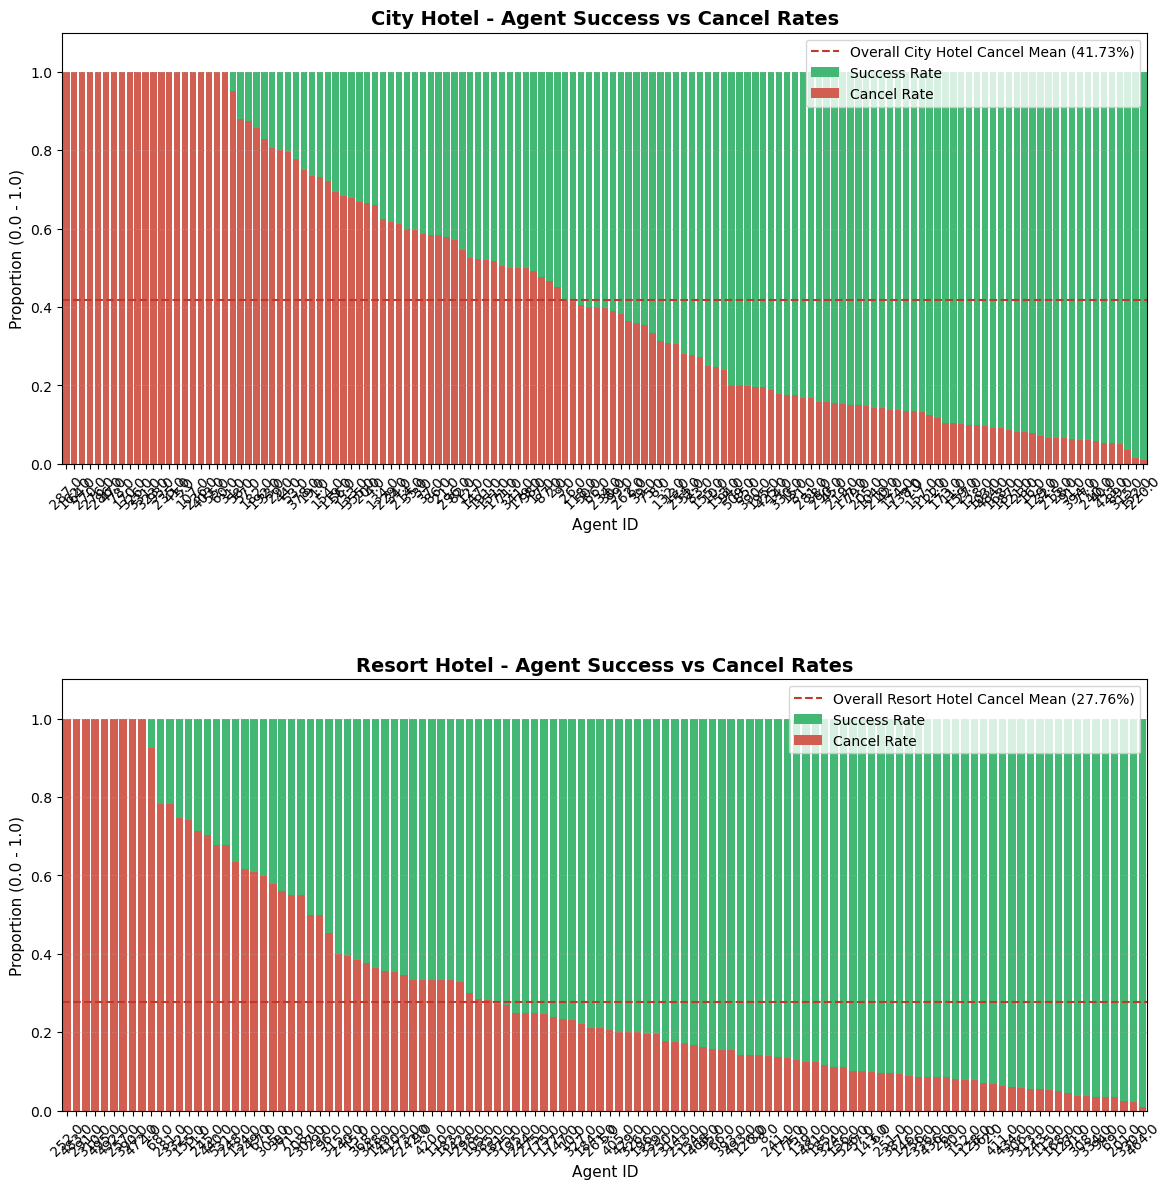

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 호텔별 총 취소 비율 계산
hotel_overall_cancel = hotel.groupby("hotel")["is_canceled"].mean()

# 2. 에이전트별 통계 계산
agent_stats = hotel.groupby(["hotel", "agent"], dropna=False)["is_canceled"].agg(["mean", "sum", "count"]).reset_index()

# 3. 최소 100건 이상 예약 + 취소 건수가 1건 이상인 에이전트 필터링
min_bookings = 1
filtered_agents = agent_stats[(agent_stats["count"] >= min_bookings) & (agent_stats["sum"] > 0)].copy()

# 4. [새로운 컬럼 추가] 예약 성공률 계산 (1 - 취소율)
filtered_agents["success_rate"] = 1 - filtered_agents["mean"]

# 5. 시각화 세팅 (누적 바 차트 그리기)
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=False)
plt.subplots_adjust(hspace=0.5)

hotel_types = ["City Hotel", "Resort Hotel"]

for i, hotel_type in enumerate(hotel_types):
    # 해당 호텔 데이터 필터링 후 취소율 높은 순으로 정렬
    df_sub = filtered_agents[filtered_agents["hotel"] == hotel_type].sort_values(by="mean", ascending=False)
    df_sub["agent"] = df_sub["agent"].astype(str)
    
    # 5-1. 먼저 전체 높이(1.0)까지 '예약 성공률'을 밑바탕에 그립니다 (녹색 계열)
    sns.barplot(ax=axes[i], x="agent", y=[1.0] * len(df_sub), data=df_sub, color="#2ecc71", label="Success Rate")
    
    # 5-2. 그 위에 '취소 비율'을 덮어씌워 누적 차트를 만듭니다 (붉은색/오렌지색 계열)
    sns.barplot(ax=axes[i], x="agent", y="mean", data=df_sub, color="#e74c3c", label="Cancel Rate")
    
    # 5-3. 호텔별 '총 취소 비율' 기준선 (붉은 점선)
    overall_cancel_mean = hotel_overall_cancel[hotel_type]
    axes[i].axhline(overall_cancel_mean, color="#c0392b", linestyle="--", linewidth=1.5, 
                    label=f"Overall {hotel_type} Cancel Mean ({overall_cancel_mean:.2%})")
    
    # 그래프 디테일 설정
    axes[i].set_title(f"{hotel_type} - Agent Success vs Cancel Rates", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Agent ID", fontsize=11)
    axes[i].set_ylabel("Proportion (0.0 - 1.0)", fontsize=11)
    axes[i].set_ylim(0, 1.1)  # 범례 공간 확보를 위해 y축 최대값을 조금 늘림
    axes[i].tick_params(axis='x', rotation=45)
    
    # 중복 범례 제거 후 깔끔하게 정렬
    handles, labels = axes[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[i].legend(by_label.values(), by_label.keys(), loc="upper right")
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)

plt.show()

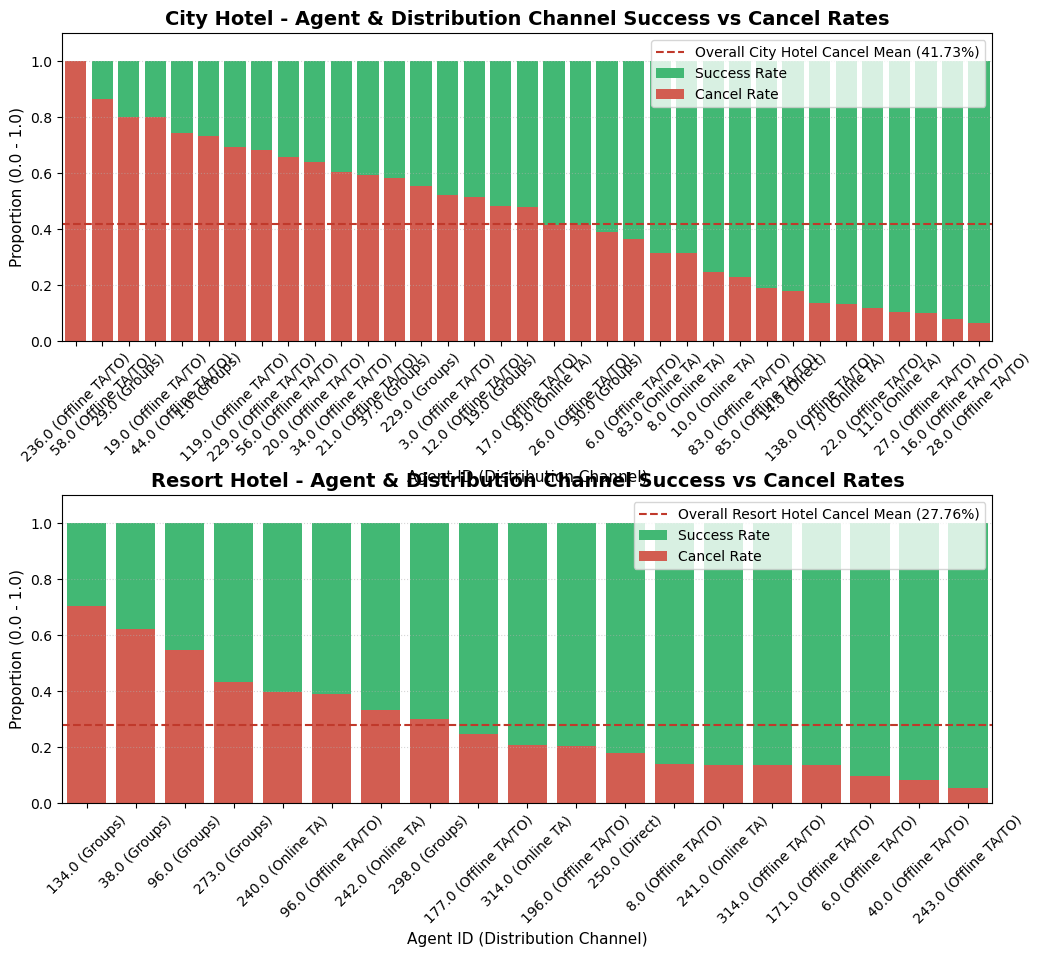

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 호텔별 총 취소 비율 계산
hotel_overall_cancel = hotel.groupby("hotel")["is_canceled"].mean()

# 2. [수정] groupby에 distribution_channel 컬럼 추가하여 함께 집계
# reset_index() 덕분에 distribution_channel도 일반 컬럼으로 쉽게 쓸 수 있습니다.
agent_stats = hotel.groupby(["hotel", "agent", "distribution_channel", "market_segment"], dropna=False)["is_canceled"].agg(["mean", "sum", "count"]).reset_index()

# 3. 최소 100건 이상 예약 + 취소 건수가 1건 이상인 에이전트 필터링
min_bookings = 200
filtered_agents = agent_stats[(agent_stats["count"] >= min_bookings) & (agent_stats["sum"] > 0)].copy()

# 4. 예약 성공률 계산 (1 - 취소율)
filtered_agents["success_rate"] = 1 - filtered_agents["mean"]

# 5. [추가] 시각화 가독성을 위해 X축 표시용 텍스트 생성 (예: "9.0 (TA/TO)")
filtered_agents["agent_combined"] = (
            filtered_agents["agent"].astype(str) + " (" + 
            # filtered_agents["distribution_channel"].astype(str) + "/" +
            filtered_agents["market_segment"].astype(str) + ")"
)


# 6. 시각화 세팅
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
plt.subplots_adjust(hspace=0.5)

hotel_types = ["City Hotel", "Resort Hotel"]

for i, hotel_type in enumerate(hotel_types):
    # 해당 호텔 데이터 필터링 후 취소율 높은 순으로 정렬
    df_sub = filtered_agents[filtered_agents["hotel"] == hotel_type].sort_values(by="mean", ascending=False)
    
    # x축 대상 컬럼을 새로 만든 'agent_combined'로 지정
    sns.barplot(ax=axes[i], x="agent_combined", y=[1.0] * len(df_sub), data=df_sub, color="#2ecc71", label="Success Rate")
    sns.barplot(ax=axes[i], x="agent_combined", y="mean", data=df_sub, color="#e74c3c", label="Cancel Rate")
    
    # 호텔별 '총 취소 비율' 기준선 (붉은 점선)
    overall_cancel_mean = hotel_overall_cancel[hotel_type]
    axes[i].axhline(overall_cancel_mean, color="#c0392b", linestyle="--", linewidth=1.5, 
                    label=f"Overall {hotel_type} Cancel Mean ({overall_cancel_mean:.2%})")
    
    # 그래프 디테일 설정
    axes[i].set_title(f"{hotel_type} - Agent & Distribution Channel Success vs Cancel Rates", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Agent ID (Distribution Channel)", fontsize=11)
    axes[i].set_ylabel("Proportion (0.0 - 1.0)", fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].tick_params(axis='x', rotation=45)
    
    # 중복 범례 제거
    handles, labels = axes[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[i].legend(by_label.values(), by_label.keys(), loc="upper right")
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)

plt.show()


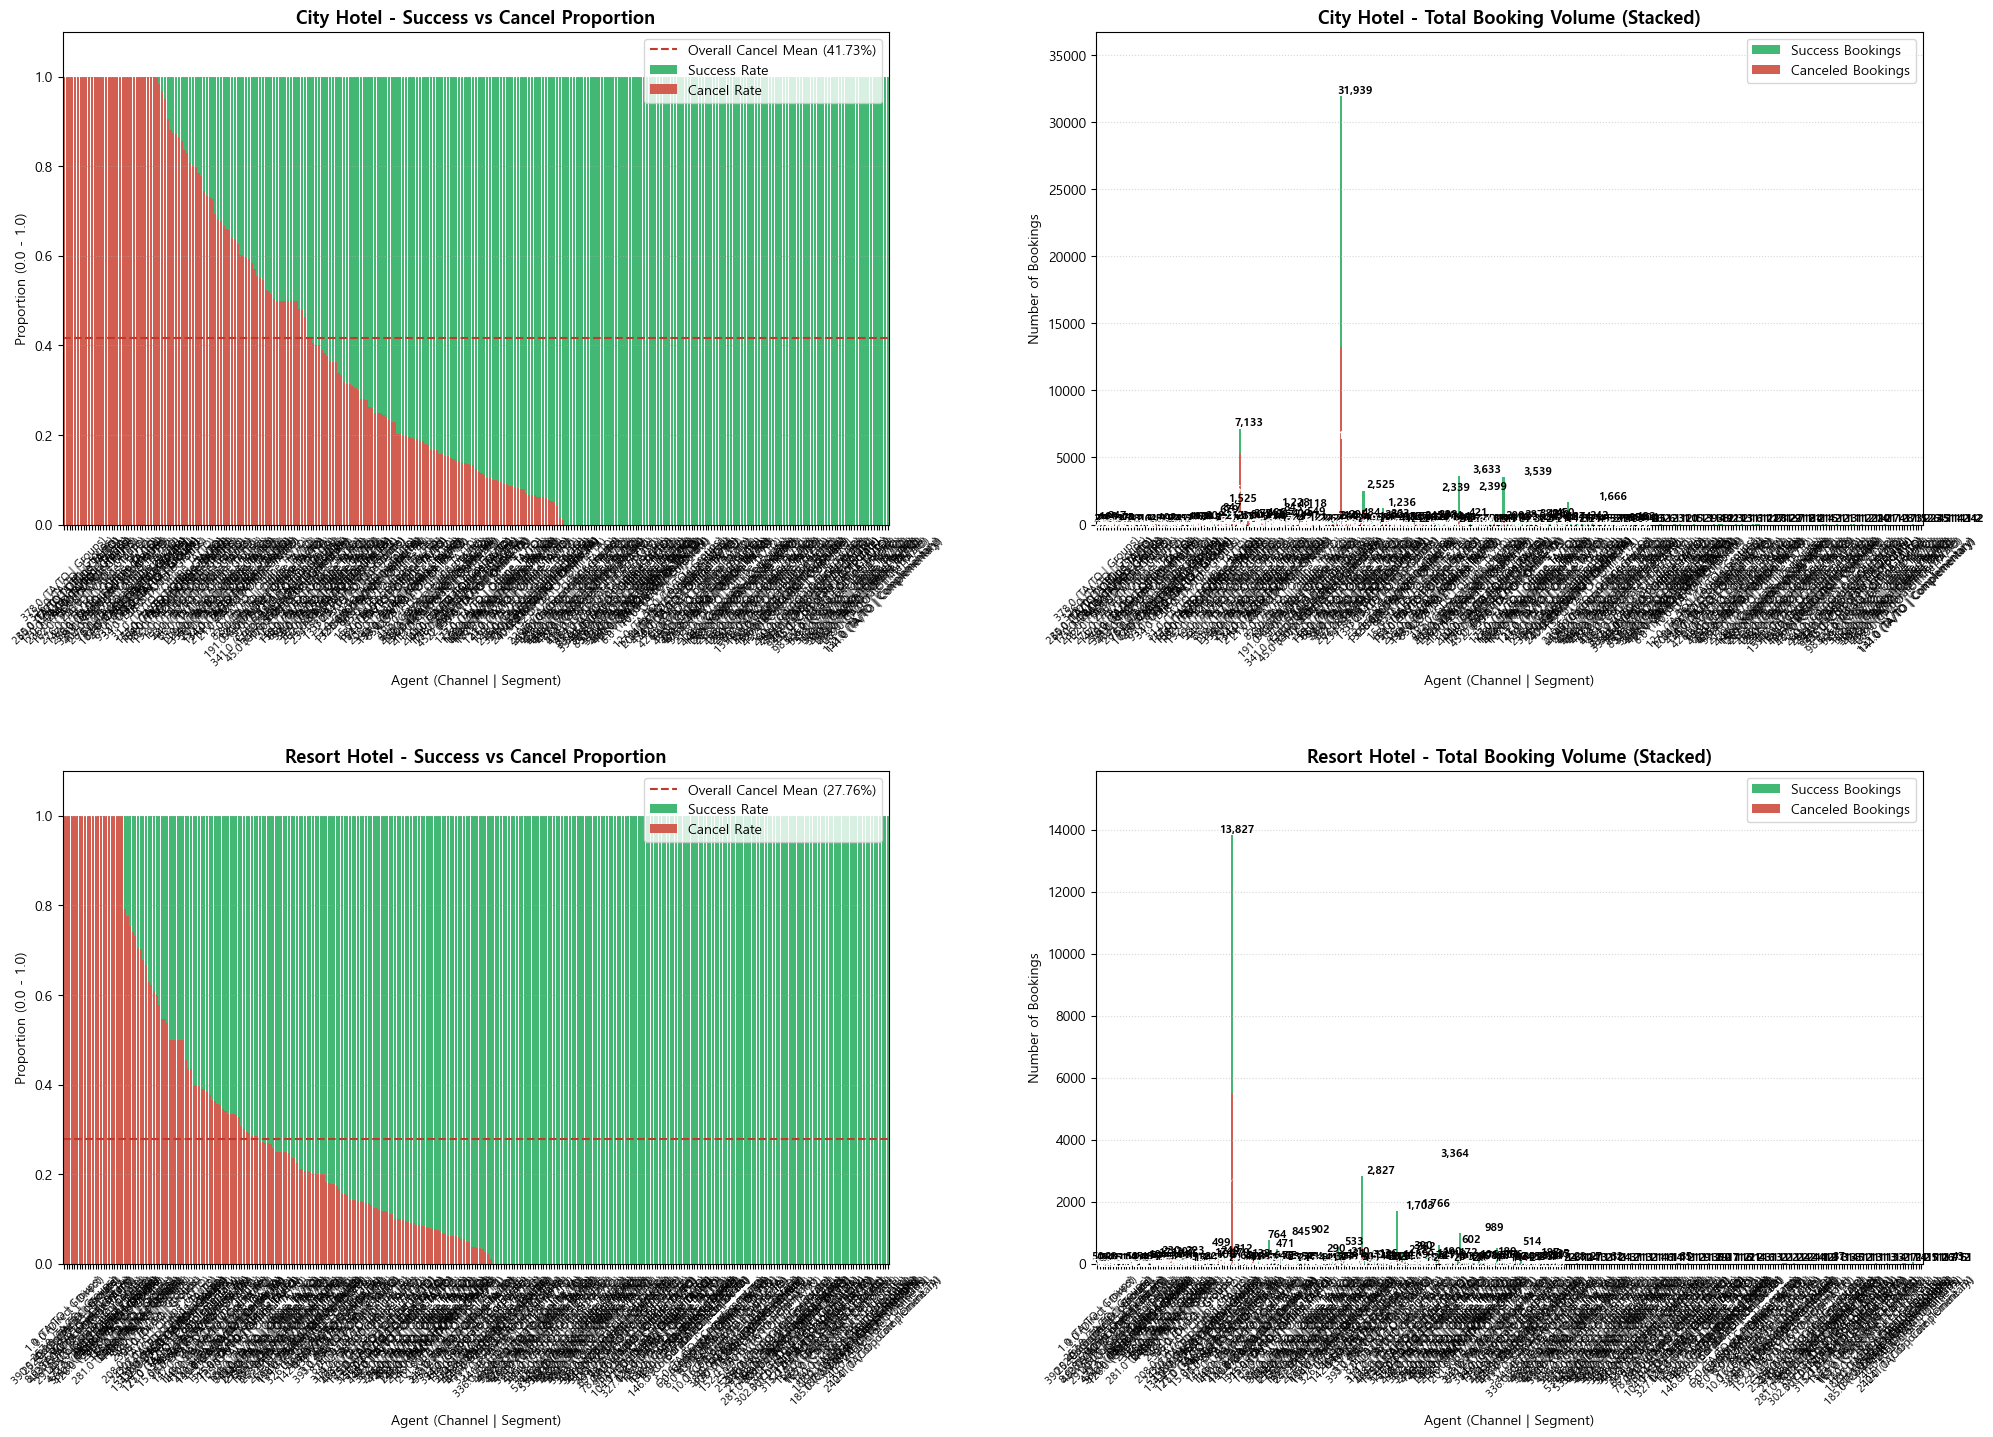

In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 호텔별 총 취소 비율 계산
hotel_overall_cancel = hotel.groupby("hotel")["is_canceled"].mean()

# 2. 다차원 그룹화 집계 (agent, 채널, 세그먼트)
agent_stats = hotel.groupby(["hotel", "agent", "distribution_channel", "market_segment"], dropna=False)["is_canceled"].agg(["mean", "sum", "count"]).reset_index()

# 3. 최소 100건 이상 예약 + 취소 건수가 1건 이상인 조합 필터링
min_bookings = 1
# filtered_agents = agent_stats[(agent_stats["count"] >= min_bookings) & (agent_stats["sum"] > 0)].copy()
filtered_agents = agent_stats[(agent_stats["count"] >= min_bookings) ].copy()


# 4. [추가] 정상 예약 건수 계산 (전체 건수 - 취소 건수)
filtered_agents["success_count"] = filtered_agents["count"] - filtered_agents["sum"]

# X축용 결합 텍스트 생성
filtered_agents["agent_combined"] = (
    filtered_agents["agent"].astype(str) + " (" + 
    filtered_agents["distribution_channel"].astype(str) + " | " + 
    filtered_agents["market_segment"].astype(str) + ")"
)

# 5. 시각화 설정 (2행 2열 구조)
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
plt.subplots_adjust(hspace=0.5, wspace=0.25)

hotel_types = ["City Hotel", "Resort Hotel"]

for i, hotel_type in enumerate(hotel_types):
    # 해당 호텔 데이터 필터링 후 취소율 높은 순으로 정렬
    df_sub = filtered_agents[filtered_agents["hotel"] == hotel_type].sort_values(by="mean", ascending=False)
    
    # ---------------- [왼쪽 그래프: 성공률 vs 취소율 비율] ----------------
    ax_ratio = axes[i, 0]
    sns.barplot(ax=ax_ratio, x="agent_combined", y=[1.0] * len(df_sub), data=df_sub, color="#2ecc71", label="Success Rate")
    sns.barplot(ax=ax_ratio, x="agent_combined", y="mean", data=df_sub, color="#e74c3c", label="Cancel Rate")
    
    overall_cancel_mean = hotel_overall_cancel[hotel_type]
    ax_ratio.axhline(overall_cancel_mean, color="#c0392b", linestyle="--", linewidth=1.5, 
                     label=f"Overall Cancel Mean ({overall_cancel_mean:.2%})")
    
    ax_ratio.set_title(f"{hotel_type} - Success vs Cancel Proportion", fontsize=13, fontweight='bold')
    ax_ratio.set_xlabel("Agent (Channel | Segment)", fontsize=10)
    ax_ratio.set_ylabel("Proportion (0.0 - 1.0)", fontsize=10)
    ax_ratio.set_ylim(0, 1.1)
    ax_ratio.tick_params(axis='x', rotation=45, labelsize=8)
    
    handles, labels = ax_ratio.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_ratio.legend(by_label.values(), by_label.keys(), loc="upper right")
    ax_ratio.grid(axis='y', linestyle=':', alpha=0.5)

    # ---------------- [수정된 오른쪽 그래프: 총 예약 건수 (정상 vs 취소 누적)] ----------------
    ax_count = axes[i, 1]
    
    # 5-1. 밑바탕에 '전체 예약 건수'를 초록색(정상 예약 베이스)으로 먼저 그립니다.
    sns.barplot(ax=ax_count, x="agent_combined", y="count", data=df_sub, color="#2ecc71", label="Success Bookings")
    
    # 5-2. 그 위에 '취소 건수(sum)'를 빨간색으로 덮어씌워 누적 차트를 만듭니다.
    sns.barplot(ax=ax_count, x="agent_combined", y="sum", data=df_sub, color="#e74c3c", label="Canceled Bookings")
    
    # 5-3. 막대 위에 '총 예약 건수'와 '취소 건수'를 텍스트로 표시
    for index, row in df_sub.reset_index(drop=True).iterrows():
        # 총 건수 표시 (막대 맨 위)
        ax_count.text(index, row["count"], f"{int(row['count']):,}", 
                      ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')
        # 취소 건수 표시 (빨간 막대 내부 혹은 위쪽)
        if row["sum"] > 0:
            ax_count.text(index, row["sum"]/2, f"{int(row['sum']):,}", 
                          ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
    ax_count.set_title(f"{hotel_type} - Total Booking Volume (Stacked)", fontsize=13, fontweight='bold')
    ax_count.set_xlabel("Agent (Channel | Segment)", fontsize=10)
    ax_count.set_ylabel("Number of Bookings", fontsize=10)
    ax_count.set_ylim(0, df_sub["count"].max() * 1.15) 
    ax_count.tick_params(axis='x', rotation=45, labelsize=8)
    ax_count.legend(loc="upper right")
    ax_count.grid(axis='y', linestyle=':', alpha=0.5)

plt.show()

In [213]:
# 에이전트별 성과 고도화 집계 (ADR과 Lead Time 추가)
agent_advanced_stats = hotel.groupby(["hotel", "agent", "distribution_channel", "market_segment"], dropna=False).agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean'),
    #avg_adr=('adr', 'mean'),                   # 평균 객실 단가
    avg_lead_time=('lead_time', 'mean')         # 평균 예약 선행일수
).reset_index()

# 100건 이상 예약 및 취소율 높은 순 정렬
agent_report = agent_advanced_stats[agent_advanced_stats['total_bookings'] >= 100].sort_values(by='cancel_rate', ascending=False)

# 상위 10개 요주의 에이전트 조합 확인
print(agent_report.head(10))

          hotel  agent distribution_channel market_segment  total_bookings  \
246  City Hotel  326.0                TA/TO         Groups             160   
8    City Hotel    5.0                TA/TO  Offline TA/TO             102   
210  City Hotel  236.0                TA/TO  Offline TA/TO             247   
5    City Hotel    3.0                TA/TO         Groups             190   
51   City Hotel   31.0                TA/TO  Offline TA/TO             162   
85   City Hotel   58.0                TA/TO         Groups             126   
162  City Hotel  154.0                TA/TO  Offline TA/TO             118   
86   City Hotel   58.0                TA/TO  Offline TA/TO             209   
49   City Hotel   29.0                TA/TO         Groups             679   
36   City Hotel   19.0                TA/TO  Offline TA/TO             847   

     canceled_bookings  cancel_rate  avg_lead_time  
246                160     1.000000      60.275000  
8                  102     1.000000

TypeError: 'value' must be an instance of str or bytes, not a float

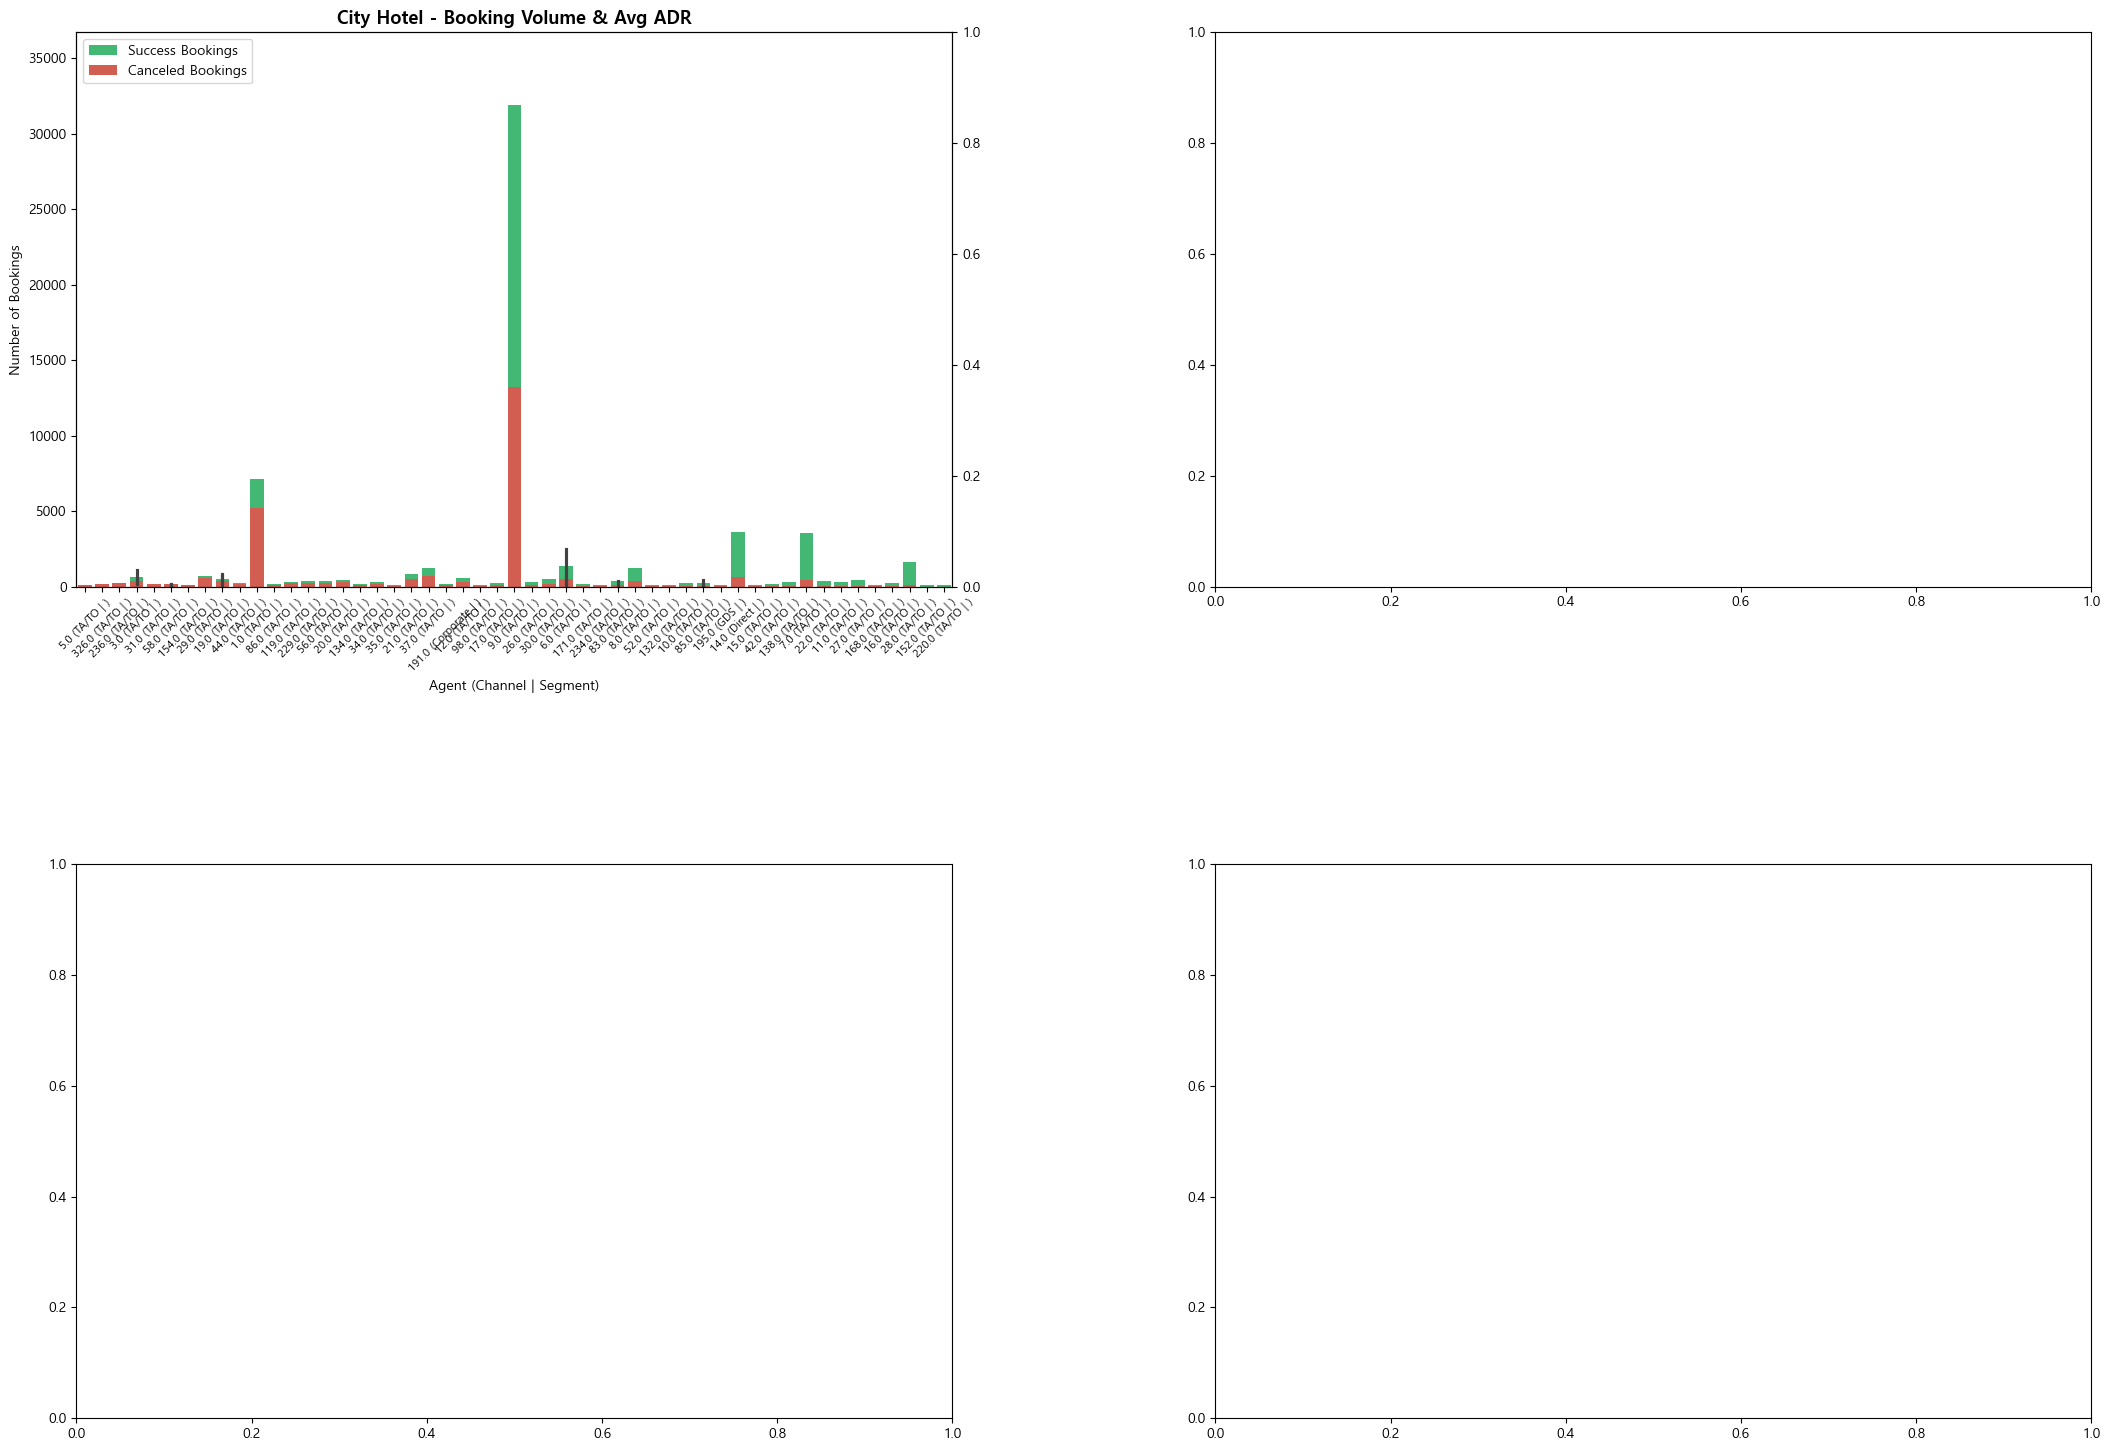

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 호텔별 총 취소 비율 계산
hotel_overall_cancel = hotel.groupby("hotel")["is_canceled"].mean()

# 2. 고도화 데이터 집계 (ADR 포함)
agent_advanced_stats = hotel.groupby(
    ["hotel", "agent", "distribution_channel", "market_segment"], dropna=False
).agg(
    count=('is_canceled', 'count'),
    sum=('is_canceled', 'sum'),
    mean=('is_canceled', 'mean'),
    #avg_adr=('adr', 'mean'),                   # 평균 객실 단가
    avg_lead_time=('lead_time', 'mean')         # 평균 예약 선행일수
).reset_index()

# 3. 최소 100건 이상 예약 + 취소 건수가 1건 이상인 조합 필터링
min_bookings = 100
filtered_agents = agent_advanced_stats[(agent_advanced_stats["count"] >= min_bookings) & (agent_advanced_stats["sum"] > 0)].copy()

# X축용 결합 텍스트 생성
filtered_agents["agent_combined"] = (
    filtered_agents["agent"].astype(str) + " (" + 
    filtered_agents["distribution_channel"].astype(str) + " | " + 
    #filtered_agents["market_segment"].astype(str) +
      ")"
)

# 4. 시각화 세팅 (2행 2열 구조)
fig, axes = plt.subplots(2, 2, figsize=(26, 18))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

hotel_types = ["City Hotel", "Resort Hotel"]

for i, hotel_type in enumerate(hotel_types):
    # 해당 호텔 데이터 필터링 후 취소율 높은 순으로 정렬
    df_sub = filtered_agents[filtered_agents["hotel"] == hotel_type].sort_values(by="mean", ascending=False)
    
    # ---------------- [왼쪽 그래프: 건수(누적 바) + 객실 단가 ADR(꺾은선 이중축)] ----------------
    ax_count = axes[i, 0]
    
    # 정상/취소 건수 누적 차트
    sns.barplot(ax=ax_count, x="agent_combined", y="count", data=df_sub, color="#2ecc71", label="Success Bookings")
    sns.barplot(ax=ax_count, x="agent_combined", y="sum", data=df_sub, color="#e74c3c", label="Canceled Bookings")
    
    ax_count.set_title(f"{hotel_type} - Booking Volume & Avg ADR", fontsize=13, fontweight='bold')
    ax_count.set_xlabel("Agent (Channel | Segment)", fontsize=10)
    ax_count.set_ylabel("Number of Bookings", fontsize=10)
    ax_count.set_ylim(0, df_sub["count"].max() * 1.15)
    ax_count.tick_params(axis='x', rotation=45, labelsize=8)
    ax_count.legend(loc="upper left")
    
    # 이중 축(Twin X)을 생성하여 오른쪽 y축에 ADR 표시
    ax_adr = ax_count.twinx()
    #ax_adr.plot(df_sub["agent_combined"], df_sub["avg_adr"], color="#f39c12", marker="o", linewidth=2, label="Avg ADR ($)")
    ax_adr.plot(df_sub["agent_combined"], df_sub["avg_lead_time"], color="#f39c12", marker="o", linewidth=2, label="Avg lead time(d))")
    ax_adr.set_ylabel("Average Daily Rate (ADR)", fontsize=10, color="#f39c12")
    ax_adr.tick_params(axis='y', labelcolor="#f39c12")
    #ax_adr.set_ylim(0, df_sub["avg_adr"].max() * 1.2)
    ax_adr.set_ylim(0, df_sub["avg_lead_time"].max() * 1.2)
    ax_adr.legend(loc="upper right")

    # ---------------- [오른쪽 그래프: 성공률 vs 취소율 비율] ----------------
    ax_ratio = axes[i, 1]
    
    sns.barplot(ax=ax_ratio, x="agent_combined", y=[1.0] * len(df_sub), data=df_sub, color="#2ecc71", label="Success Rate")
    sns.barplot(ax=ax_ratio, x="agent_combined", y="mean", data=df_sub, color="#e74c3c", label="Cancel Rate")
    
    # 호텔별 전체 평균 취소율 기준선
    overall_cancel_mean = hotel_overall_cancel[hotel_type]
    ax_ratio.axhline(overall_cancel_mean, color="#c0392b", linestyle="--", linewidth=1.5, 
                     label=f"Overall Cancel Mean ({overall_cancel_mean:.2%})")
    
    ax_ratio.set_title(f"{hotel_type} - Success vs Cancel Proportion", fontsize=13, fontweight='bold')
    ax_ratio.set_xlabel("Agent (Channel | Segment)", fontsize=10)
    ax_ratio.set_ylabel("Proportion (0.0 - 1.0)", fontsize=10)
    ax_ratio.set_ylim(0, 1.1)
    ax_ratio.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 범례 및 그리드 정리
    handles, labels = ax_ratio.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_ratio.legend(by_label.values(), by_label.keys(), loc="upper right")
    ax_ratio.grid(axis='y', linestyle=':', alpha=0.5)

plt.show()

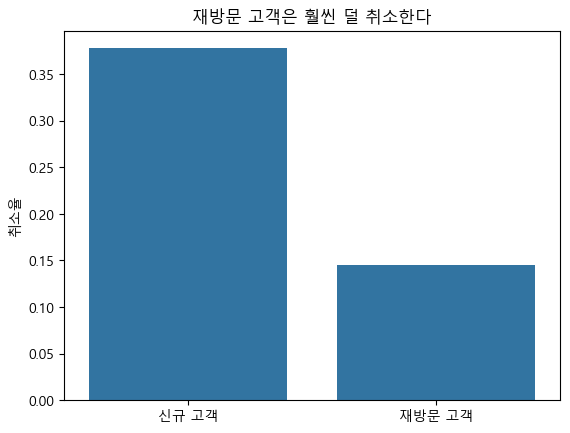

In [211]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 속성 정의
font_style = {'family': 'Malgun Gothic', 'size': 12}

# plt.plot([1, 2, 3], [4, 5, 6])
# plt.title('그래프 제목', fontdict=font_style) # 한글 타이틀 적용
# plt.xlabel('X축 라벨', fontdict=font_style)   # 한글 라벨 적용
# plt.show()

hotel['고객구분'] = hotel['is_repeated_guest'].map({0: '신규 고객', 1: '재방문 고객'})

t = hotel.groupby('고객구분')['is_canceled'].agg(예약='count', 취소='sum')
t['취소율'] = (t['취소'] / t['예약'] * 100).round(1)
t

sns.barplot(data=hotel, x='고객구분', y='is_canceled', errorbar=None)
plt.title('재방문 고객은 훨씬 덜 취소한다')
plt.xlabel('')
plt.ylabel('취소율')
plt.show()

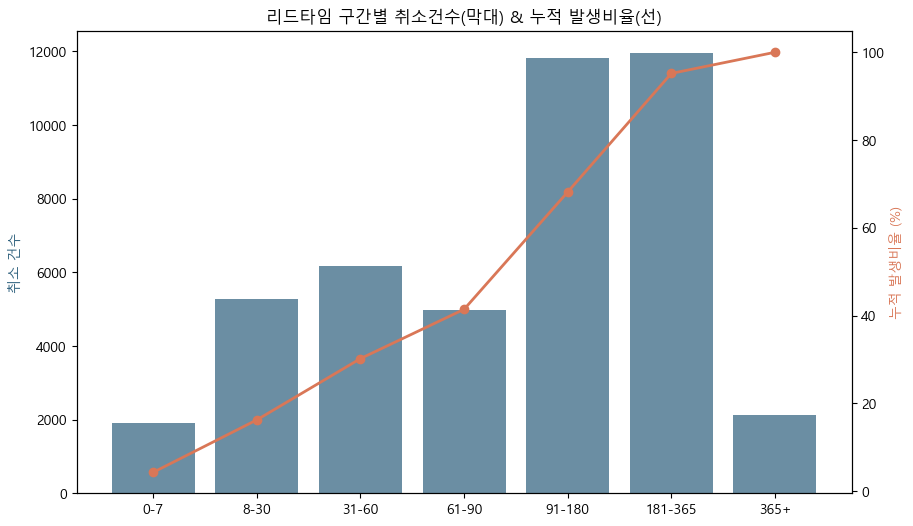

In [222]:
import matplotlib.pyplot as plt

# 폰트 속성 정의
import platform
font_style = {'family': 'Malgun Gothic', 'size': 12}

#plt.rcParams["font.family"] = "AppleGothic"
#plt.rcParams["axes.unicode_minus"] = False
# 운영체제를 확인하여 폰트 자동 지정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

hotel["lead_bin"] = pd.cut(hotel["lead_time"], bins=[-1,7,30,60,90,180,365,10000],
                             labels=["0-7","8-30","31-60","61-90","91-180","181-365","365+"])

bin_sum = hotel.groupby("lead_bin", observed=True)["is_canceled"].sum().sort_index()
누적비율 = (bin_sum / hotel["is_canceled"].sum() * 100).cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(bin_sum.index, bin_sum, color="#2C5F7C", alpha=0.7)
ax1.set_ylabel("취소 건수", color="#2C5F7C")

ax2 = ax1.twinx()
ax2.plot(bin_sum.index, 누적비율, color="#D97757", marker="o", linewidth=2)
ax2.set_ylabel("누적 발생비율 (%)", color="#D97757")

plt.title("리드타임 구간별 취소건수(막대) & 누적 발생비율(선)")
plt.show()


<Axes: xlabel='market_segment'>

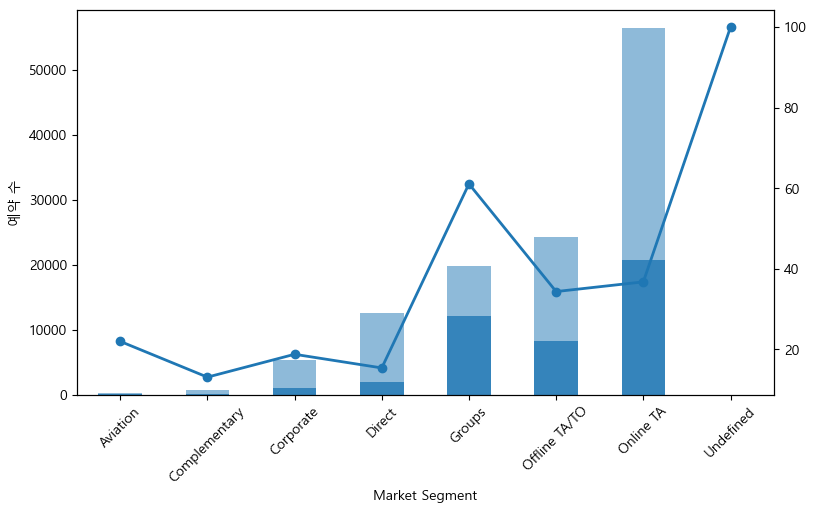

In [209]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Market Segment별 총 예약 수
total_count = (
    hotel.groupby('market_segment')['is_canceled']
         .count()
)

# Market Segment별 예약 취소 횟수
cancel_count = (
    hotel[hotel['is_canceled'] == 1]
    .groupby('market_segment')['is_canceled']
    .count()
)

# Market Segment별 예약 취소율
cancel_rate = (
    hotel.groupby('market_segment')['is_canceled']
         .mean() * 100
)

# 그래프
fig, ax1 = plt.subplots(figsize=(9, 5))

# 총 예약 수 → 막대
total_count.plot(
    kind='bar',
    ax=ax1,
    alpha=0.5,
    label='총 예약 수'
)

# 취소 횟수 → 막대
cancel_count.plot(
    kind='bar',
    ax=ax1,
    alpha=0.8,
    label='예약 취소 횟수'
)

ax1.set_xlabel('Market Segment')
ax1.set_ylabel('예약 수')
ax1.tick_params(axis='x', rotation=45)

# 취소율 → 선그래프
ax2 = ax1.twinx()

cancel_rate.plot(
    kind='line',
    ax=ax2,
    marker='o',
    linewidth=2,
    label='예약 취소율'
)



In [127]:
display(hotel.groupby("agent")["is_canceled"].agg(["mean","sum", "count"]).sort_values(by='sum', ascending=False))
mask = hotel['agent'] == '9.0'
hotel[mask]

###### 정책 보완
## agent - 
## 취소한 사람이 반복적 취소 - 취소에 대한 패널티 필요
## 리스타임 - 예약을 허용 기간이 관리 
## 단체 예약에 대한 '예약금'
## 재방문 고객의 예약율 저조 --> 재방문 유치 마케팅 

,mean,sum,count
agent,,,
9.0,0.415006,13264,31961
240.0,0.393909,5484,13922
1.0,0.734251,5280,7191
6.0,0.311550,1025,3290
19.0,0.735156,780,1061
...,...,...,...
294.0,0.000000,0,1
295.0,0.000000,0,4
299.0,0.000000,0,1


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [181]:
## agent 문제 검토
print('agent 컬럼 is null:', hotel['agent'].isna().sum() )
#print('agent 컬럼 데이터 카운트:\n', hotel['agent'].value_counts())

display(hotel.groupby("agent",dropna=False )["is_canceled"].agg(["mean","sum", "count"]).sort_values(by='sum', ascending=False))
#display(hotel.groupby("agent" )["is_canceled"].agg(["mean","sum", "count"]).sort_values(by='sum', ascending=False))

pd.crosstab(hotel['agent'], hotel['is_canceled'], dropna=False)


agent 컬럼 is null: 16340


,mean,sum,count
agent,,,
9.0,0.415006,13264,31961
240.0,0.393909,5484,13922
1.0,0.734251,5280,7191
NaN,0.246634,4030,16340
6.0,0.311550,1025,3290
...,...,...,...
295.0,0.000000,0,4
299.0,0.000000,0,1
300.0,0.000000,0,1


is_canceled,0,1
agent,,
1.0,1911,5280
2.0,128,34
3.0,565,771
4.0,16,31
5.0,181,149
...,...,...
526.0,9,1
527.0,35,0
531.0,22,46


In [136]:
filtered = hotel[
    (hotel['previous_cancellations'] >= 1) &
    (hotel['is_canceled'] == 1)
]

print("총 인원:", len(filtered))
print(filtered['agent'].value_counts())

총 인원: 5942
agent
1.0      2429
19.0      348
9.0       339
6.0       310
29.0      181
         ... 
42.0        1
104.0       1
27.0        1
138.0       1
153.0       1
Name: count, Length: 84, dtype: int64


ValueError: Could not interpret value `고객구분` for `x`. An entry with this name does not appear in `data`.

In [204]:
# 분석할 주요 범주형 컬럼 리스트 
category_cols = ['hotel', 'market_segment', 'distribution_channel', 'agent', 'meal', 'is_repeated_guest'
                 ,'previous_cancellations','previous_bookings_not_canceled', 'lead_time','country'
                 ,'reserved_room_type', 'assigned_room_type', 'booking_changes','days_in_waiting_list'
                 ,'required_car_parking_spaces','total_of_special_requests','reservation_status', 'reservations_status_date'
                 ,'arrival_date_year','arrival_date_month']

for col in category_cols:
    print(f"\n=== {col}별 예약 취소율 ===")
    # 각 그룹별 데이터 개수(count)와 취소율(mean) 계산
    analysis = hotel.groupby(col, dropna=False )['is_canceled'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)
    display(analysis)




=== hotel별 예약 취소율 ===


,count,sum,mean
hotel,,,
City Hotel,79330,33102,0.417270
Resort Hotel,40060,11122,0.277634



=== market_segment별 예약 취소율 ===


,count,sum,mean
market_segment,,,
Online TA,56477,20739,0.367211
Groups,19811,12097,0.610620
Offline TA/TO,24219,8311,0.343160
Direct,12606,1934,0.153419
Corporate,5295,992,0.187347
Complementary,743,97,0.130552
Aviation,237,52,0.219409
Undefined,2,2,1.000000



=== distribution_channel별 예약 취소율 ===


...

,count,sum,mean
total_of_special_requests,,,
0,70318,33556,0.477204
1,33226,7318,0.220249
2,12969,2866,0.220989
3,2497,446,0.178614
4,340,36,0.105882
5,40,2,0.050000



=== reservation_status별 예약 취소율 ===


,count,sum,mean
reservation_status,,,
Canceled,43017,43017,1.0
No-Show,1207,1207,1.0
Check-Out,75166,0,0.0



=== reservations_status_date별 예약 취소율 ===


KeyError: 'reservations_status_date'

In [173]:
# 제안 1 검증 — 거주지 × 예약시점

hotel['현지여부'] = (hotel['country'] == 'PRT')   # 이 호텔은 포르투갈 소재 --> 데이터에서 가능 많은 나라 --> 현지로 파악 
hotel['장기예약'] = hotel['lead_time'] >= 90

t = hotel.groupby(['현지여부', '장기예약'])['is_canceled'].agg(예약='count', 취소='sum')
t['취소율'] = (t['취소'] / t['예약'] * 100).round(1)
t.index = ['해외·단기', '해외·장기', '현지·단기', '현지·장기']
print(t.to_string())

해외장기 = hotel[(~hotel['현지여부']) & (hotel['장기예약'])]
정상 = len(해외장기) - 해외장기['is_canceled'].sum()
print(f"\n전원 적용 시 애먼 사람: {정상:,}명")

          예약     취소   취소율
해외·단기  41241   8362  20.3
해외·장기  29559   8343  28.2
현지·단기  26725   9885  37.0
현지·장기  21865  17634  80.6

전원 적용 시 애먼 사람: 21,216명


In [128]:
# 분석할 주요 범주형 컬럼 리스트 for hotel2 (중복제거 데이터)
category_cols = ['hotel', 'market_segment', 'distribution_channel', 'meal', 'is_repeated_guest'
                 ,'previous_cancellations','previous_bookings_not_canceled', 'lead_time','country'
                 ,'reserved_room_type', 'assigned_room_type', 'booking_changes','days_in_waiting_list'
                 ,'required_car_parking_spaces','total_of_special_requests','reservation_status'
                 ,'arrival_date_year','arrival_date_month']

for col in category_cols:
    print(f"\n=== {col}별 예약 취소율 ===")
    # 각 그룹별 데이터 개수(count)와 취소율(mean) 계산
    analysis = hotel2.groupby(col)['is_canceled'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)
    display(analysis)


=== hotel별 예약 취소율 ===


,count,sum,mean
hotel,,,
City Hotel,52913,15968,0.301778
Resort Hotel,33374,7921,0.237340



=== market_segment별 예약 취소율 ===


,count,sum,mean
market_segment,,,
Online TA,51231,18166,0.354590
Offline TA/TO,13617,2046,0.150253
Direct,11704,1721,0.147044
Groups,4638,1318,0.284174
Corporate,4169,504,0.120892
Complementary,700,88,0.125714
Aviation,226,44,0.194690
Undefined,2,2,1.000000



=== distribution_channel별 예약 취소율 ===


...

,count,sum,mean
reservation_status,,,
Canceled,22883,22883,1.0
No-Show,1006,1006,1.0
Check-Out,62398,0,0.0



=== arrival_date_year별 예약 취소율 ===


,count,sum,mean
arrival_date_year,,,
2016,41752,11131,0.266598
2017,31375,10082,0.321339
2015,13160,2676,0.203343



=== arrival_date_month별 예약 취소율 ===


,count,sum,mean
arrival_date_month,,,
August,11136,3603,0.323545
July,9946,3176,0.319324
May,8244,2431,0.294881
April,7811,2398,0.307003
June,7676,2344,0.305367
March,7410,1821,0.245749
October,6805,1631,0.239677
September,6561,1628,0.248133
February,6025,1405,0.233195


In [141]:
#### 호텔별 
# 분석할 주요 범주형 컬럼 리스트 for hotelㅌ
#df = hotel[hotel['hotel'] == 'City Hotel']

category_cols = [ 'market_segment', 'distribution_channel', 'meal', 'is_repeated_guest' , 'agent'
                 ,'previous_cancellations','previous_bookings_not_canceled', 'lead_time','country'
                 ,'reserved_room_type', 'assigned_room_type', 'booking_changes','days_in_waiting_list'
                 ,'required_car_parking_spaces','total_of_special_requests','reservation_status'
                 ,'arrival_date_year','arrival_date_month']

for col in category_cols:
    print(f"\n=== {col}별 예약 취소율 ===")
    # 각 그룹별 데이터 개수(count)와 취소율(mean) 계산
    analysis = hotel.groupby(['hotel', col ])['is_canceled'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)
    display(analysis)



=== market_segment별 예약 취소율 ===


count    sum      mean
hotel        market_segment                        
City Hotel   Online TA       38748  14491  0.373981
             Groups          13975   9623  0.688587
             Offline TA/TO   16747   7173  0.428316
Resort Hotel Online TA       17729   6248  0.352417
             Groups           5836   2474  0.423920
             Offline TA/TO    7472   1138  0.152302
City Hotel   Direct           6093   1056  0.173314
Resort Hotel Direct           6513    878  0.134807
City Hotel   Corporate        2986    641  0.214668
Resort Hotel Corporate        2309    351  0.152014
City Hotel   Complementary     542     64  0.118081
             Aviation          237     52  0.219409
Resort Hotel Complementary     201     33  0.164179
City Hotel   Undefined           2      2  1.000000


=== distribution_channel별 예약 취소율 ===


count    sum      mean
hotel        distribution_channel                        
City Hotel   TA/TO                 68945  31043  0.450257
Resort Hotel TA/TO                 28925   9109  0.314918
             Direct                 7865   1325  0.168468
City Hotel   Direct                 6780   1232  0.181711
             Corporate              3408    786  0.230634
Resort Hotel Corporate              3269    688  0.210462
City Hotel   GDS                     193     37  0.191710
             Undefined                 4      4  1.000000
Resort Hotel Undefined                 1      0  0.000000


=== meal별 예약 취소율 ===


...

,,count,sum,mean
hotel,reservation_status,,,
City Hotel,Canceled,32186,32186,1.0
Resort Hotel,Canceled,10831,10831,1.0
City Hotel,No-Show,916,916,1.0
Resort Hotel,No-Show,291,291,1.0
City Hotel,Check-Out,46228,0,0.0
Resort Hotel,Check-Out,28938,0,0.0



=== arrival_date_year별 예약 취소율 ===


count    sum      mean
hotel        arrival_date_year                        
City Hotel   2016               38140  15407  0.403959
             2017               27508  11691  0.425004
             2015               13682   6004  0.438825
Resort Hotel 2016               18567   4930  0.265525
             2017               13179   4054  0.307611
             2015                8314   2138  0.257157


=== arrival_date_month별 예약 취소율 ===


count   sum      mean
hotel        arrival_date_month                       
City Hotel   May                  8232  3653  0.443756
             August               8983  3602  0.400980
             June                 7894  3528  0.446922
             April                7480  3465  0.463235
             July                 8088  3306  0.408754
             October              7605  3268  0.429717
             September            7400  3110  0.420270
             March                6458  2386  0.369464
             February             4965  1901  0.382880
             December             4132  1740  0.421104
             November             4357  1661  0.381226
Resort Hotel August               4894  1637  0.334491
City Hotel   January              3736  1482  0.396681
Resort Hotel July                 4573  1436  0.314017
             April                3609  1059  0.293433
             May                  3559  1024  0.287721
             June                 3045  1007  0.330706
             September            3108  1006  0.323681
             October              3555   978  0.275105
             February             3103   795  0.256204
             March                3336   763  0.228717
             December             2648   631  0.238293
             November             2437   461  0.189167
             January              2193   325  0.148199

In [90]:
## market_segment 컬럼 점검
hotel['market_segment'].isna().sum()
hotel['market_segment'].value_counts()
mask = hotel['market_segment']=='Undefined'
hotel[mask]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,B,B,0,NaN,NaN,0,0,1,Canceled,2015-08-01
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,B,B,0,NaN,NaN,0,0,2,Canceled,2015-08-04


In [97]:
##호텔별 + 마켓 세그먼트별 취소율
mask = hotel["is_canceled"] == 1
df = hotel
market_segment_cancel_summary = (
    df
    .groupby(['hotel', 'market_segment'])["is_canceled"]
    .agg(["count", "sum", "mean"])
    .sort_values(by='sum', ascending=False)
)
display(market_segment_cancel_summary)

count    sum      mean
hotel        market_segment                        
City Hotel   Online TA       38748  14491  0.373981
             Groups          13975   9623  0.688587
             Offline TA/TO   16747   7173  0.428316
Resort Hotel Online TA       17729   6248  0.352417
             Groups           5836   2474  0.423920
             Offline TA/TO    7472   1138  0.152302
City Hotel   Direct           6093   1056  0.173314
Resort Hotel Direct           6513    878  0.134807
City Hotel   Corporate        2986    641  0.214668
Resort Hotel Corporate        2309    351  0.152014
City Hotel   Complementary     542     64  0.118081
             Aviation          237     52  0.219409
Resort Hotel Complementary     201     33  0.164179
City Hotel   Undefined           2      2  1.000000


=== hotel별 예약 취소율 ===


,count,mean
hotel,,
City Hotel,79330,0.417270
Resort Hotel,40060,0.277634



=== market_segment별 예약 취소율 ===


,count,mean
market_segment,,
Undefined,2,1.000000
Groups,19811,0.610620
Online TA,56477,0.367211
Offline TA/TO,24219,0.343160
Aviation,237,0.219409
Corporate,5295,0.187347
Direct,12606,0.153419
Complementary,743,0.130552



=== distribution_channel별 예약 취소율 ===


,count,mean
distribution_channel,,
Undefined,5,0.800000
TA/TO,97870,0.410259
Corporate,6677,0.220758
GDS,193,0.191710
Direct,14645,0.174599



=== meal별 예약 취소율 ===


,count,mean
meal,,
FB,798,0.598997
BB,92310,0.373849
SC,10650,0.372394
HB,14463,0.344603
Undefined,1169,0.244654



=== is_repeated_guest별 예약 취소율 ===


,count,mean
is_repeated_guest,,
0,115580,0.377851
1,3810,0.144882


In [57]:
# 방 일치 여부에 따른 취소율 확인
print(hotel.groupby('room_matched')['is_canceled'].agg(['count','sum', 'mean']))

KeyError: 'room_matched'

In [39]:


##### 취소 정보들만 추출
##1. 취소 컬럼 데이터 확인
print("hotel canceled column NA:" , hotel['is_canceled'].isna().sum() )

print('여부 객수 확인:' , hotel.is_canceled.value_counts() )

##### 중복 제거된 hotel에서 취소건만
mask = hotel['is_canceled']==1






hotel2 canceled column NA: 0
여부 객수 확인: is_canceled
0    62398
1    23889
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,A,A,0,240.0,NaN,0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,D,D,0,15.0,NaN,0,0,0,Canceled,2015-04-22
10,Resort Hotel,1,23,2015,July,27,1,0,4,2,...,E,E,0,240.0,NaN,0,0,0,Canceled,2015-06-23
27,Resort Hotel,1,60,2015,July,27,1,2,5,2,...,E,E,0,240.0,NaN,0,0,2,Canceled,2015-05-11
32,Resort Hotel,1,96,2015,July,27,1,2,8,2,...,E,E,0,NaN,NaN,0,0,2,Canceled,2015-05-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110280,City Hotel,1,132,2017,April,17,25,0,0,0,...,D,K,1,9.0,NaN,0,0,3,Canceled,2017-04-25
111355,City Hotel,1,4,2017,June,23,5,1,0,1,...,A,A,0,NaN,238.0,0,0,0,Canceled,2017-06-05
111924,City Hotel,1,7,2017,May,22,31,0,1,1,...,A,A,0,NaN,238.0,0,0,0,Canceled,2017-05-31
111925,City Hotel,1,6,2017,July,29,17,1,0,1,...,A,D,0,NaN,238.0,0,0,0,No-Show,2017-07-17


In [37]:
## 순우님
grp = hotel.groupby(list(hotel.columns), dropna=False).size().sort_values(ascending=False)
print(f"한 묶음 최대 겹침: {grp.max()}건\n")

top = dict(zip(hotel.columns, grp.index[0]))
for k in ['hotel','arrival_date_year','arrival_date_month','arrival_date_day_of_month',
          'lead_time','adults','country','market_segment','reserved_room_type',
          'total_of_special_requests','booking_changes','is_canceled']:
    print(f"  {k:<28} {top[k]}")

한 묶음 최대 겹침: 180건

  hotel                        City Hotel
  arrival_date_year            2016
  arrival_date_month           November
  arrival_date_day_of_month    7
  lead_time                    277
  adults                       2
  country                      PRT
  market_segment               Groups
  reserved_room_type           A
  total_of_special_requests    0
  booking_changes              0
  is_canceled                  1


In [47]:
## 순우님
na = hotel.isna().sum()
#print(na)
na = na[na > 0].sort_values(ascending=False)
pd.DataFrame({'결측 수': na, '비율(%)': (na / len(hotel) * 100).round(2)})

,결측 수,비율(%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [52]:
# distribution_channel 컬럼 검토
pd.crosstab(hotel['distribution_channel'], hotel['agent'].isna(), normalize='index') \
  .mul(100).round(1).rename(columns={False: 'agent 있음(%)', True: 'agent 없음(%)'})

agent,agent 있음(%),agent 없음(%)
distribution_channel,,
Corporate,17.0,83.0
Direct,47.9,52.1
GDS,99.0,1.0
TA/TO,96.8,3.2
Undefined,40.0,60.0
